# 03 - Model Experiments

This notebook trains and evaluates the two main modeling approaches:
1. Fine-tuned ResNet-18 (reference implementation)
2. DenseNet-Attention (student-developed model)

Both are compared on the same test set with identical preprocessing.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import get_dataloaders
from src.models import get_model, get_optimizer
from src.train import run_experiment
from src.evaluate import (
    evaluate_model, plot_confusion_matrix, plot_roc_curve,
    plot_training_history, plot_metrics_comparison,
    generate_gradcam, plot_gradcam_grid,
)
from src.utils import set_seed, get_device, load_config, save_results, count_parameters

plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

config = load_config("../configs/default.yaml")
device = get_device()
DATA_ROOT = "../data/chest_xray"
SEED = config["reproducibility"]["seed"]

print(f"Device: {device}")

Device: cuda


In [2]:
set_seed(SEED)

dataloaders = get_dataloaders(
    DATA_ROOT,
    augmentation="standard",
    image_size=config["data"]["image_size"],
    batch_size=config["training"]["batch_size"],
    val_split=config["data"]["val_split"],
    num_workers=0,
    seed=SEED,
)

print(f"Dataset info: {dataloaders['info']}")

Dataset info: {'train_size': 4447, 'val_size': 785, 'test_size': 624, 'train_class_dist': {np.int64(0): np.int64(1147), np.int64(1): np.int64(3300)}, 'val_class_dist': {np.int64(0): np.int64(202), np.int64(1): np.int64(583)}, 'test_class_dist': {np.int64(0): np.int64(234), np.int64(1): np.int64(390)}, 'class_names': ['NORMAL', 'PNEUMONIA']}


## Model 1: Fine-tuned ResNet-18

In [3]:
set_seed(SEED)

resnet_model = get_model(
    "resnet18_finetune",
    pretrained=True,
    dropout=config["model"]["dropout"],
)

params = count_parameters(resnet_model)
print(f"ResNet-18 parameters: {params['total']:,} total, {params['trainable']:,} trainable")

resnet_config = config.copy()
resnet_config["model"]["use_focal_loss"] = False

resnet_history = run_experiment(
    model_name="resnet18_finetune",
    model=resnet_model,
    dataloaders=dataloaders,
    device=device,
    config=resnet_config,
    experiment_name="resnet18_finetune",
)

ResNet-18 parameters: 11,177,025 total, 11,177,025 trainable
Epoch   1/15 | Train Loss: 0.0779 | Val Loss: 0.0344 | Val AUROC: 0.9984 | F1: 0.9567 *
Epoch   2/15 | Train Loss: 0.0497 | Val Loss: 0.0545 | Val AUROC: 0.9983 | F1: 0.9240 
Epoch   3/15 | Train Loss: 0.0464 | Val Loss: 0.0332 | Val AUROC: 0.9990 | F1: 0.9584 *
Epoch   4/15 | Train Loss: 0.0342 | Val Loss: 0.0170 | Val AUROC: 0.9995 | F1: 0.9739 *
Epoch   5/15 | Train Loss: 0.0313 | Val Loss: 0.0311 | Val AUROC: 0.9996 | F1: 0.9615 *
Epoch   6/15 | Train Loss: 0.0238 | Val Loss: 0.0200 | Val AUROC: 0.9997 | F1: 0.9708 *
Epoch   7/15 | Train Loss: 0.0186 | Val Loss: 0.0145 | Val AUROC: 0.9994 | F1: 0.9835 
Epoch   8/15 | Train Loss: 0.0158 | Val Loss: 0.0164 | Val AUROC: 0.9995 | F1: 0.9771 
Epoch   9/15 | Train Loss: 0.0165 | Val Loss: 0.0163 | Val AUROC: 0.9996 | F1: 0.9772 
Epoch  10/15 | Train Loss: 0.0108 | Val Loss: 0.0188 | Val AUROC: 0.9997 | F1: 0.9772 *
Epoch  11/15 | Train Loss: 0.0132 | Val Loss: 0.0126 | Val AURO

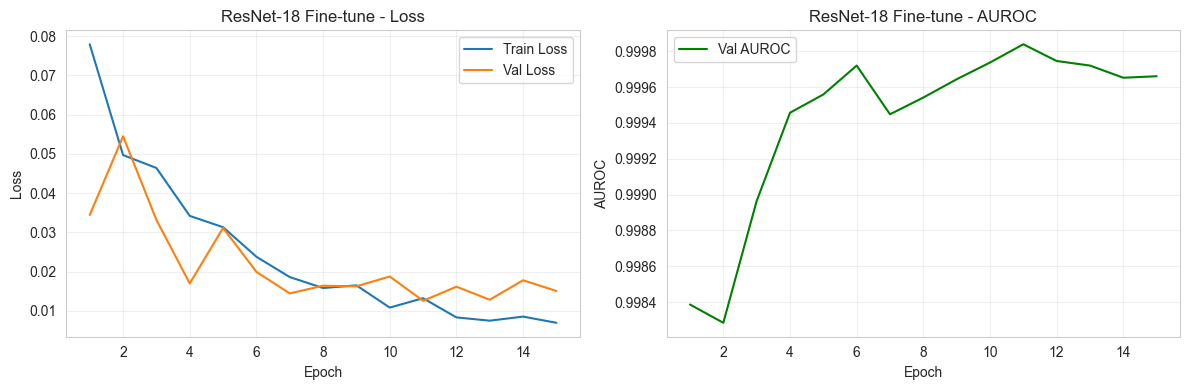

In [4]:
fig = plot_training_history(resnet_history["history"], title="ResNet-18 Fine-tune")
plt.savefig("../results/resnet18_training.png", bbox_inches="tight")
plt.show()

In [5]:
resnet_test = evaluate_model(resnet_model, dataloaders["test"], device)

print("ResNet-18 Fine-tune - Test Results:")
for key in ["auroc", "f1_macro", "sensitivity", "specificity", "precision", "npv", "accuracy"]:
    print(f"  {key:>15s}: {resnet_test['metrics'][key]:.4f}")

print(f"\nThreshold analysis:")
for key, val in resnet_test["threshold_analysis"].items():
    print(f"  {key}: {val:.4f}")

ResNet-18 Fine-tune - Test Results:
            auroc: 0.9855
         f1_macro: 0.8952
      sensitivity: 0.9949
      specificity: 0.7607
        precision: 0.8739
              npv: 0.9889
         accuracy: 0.9071

Threshold analysis:
  youden_threshold: 0.9931
  youden_sensitivity: 0.9667
  youden_specificity: 0.9188
  sensitivity95_threshold: 0.0000


## Model 2: DenseNet-Attention (Student-Developed)

In [6]:
set_seed(SEED)

densenet_model = get_model(
    "densenet_attention",
    pretrained=True,
    dropout=config["model"]["dropout"],
    use_attention=config["model"]["use_attention"],
)

params = count_parameters(densenet_model)
print(f"DenseNet-Attention parameters: {params['total']:,} total, {params['trainable']:,} trainable")

densenet_history = run_experiment(
    model_name="densenet_attention",
    model=densenet_model,
    dataloaders=dataloaders,
    device=device,
    config=config,
    experiment_name="densenet_attention",
)

DenseNet-Attention parameters: 7,347,585 total, 7,347,585 trainable
Epoch   1/15 | Train Loss: 0.0985 | Val Loss: 0.0363 | Val AUROC: 0.9971 | F1: 0.9658 *
Epoch   2/15 | Train Loss: 0.0542 | Val Loss: 0.0371 | Val AUROC: 0.9975 | F1: 0.9598 *
Epoch   3/15 | Train Loss: 0.0374 | Val Loss: 0.0283 | Val AUROC: 0.9989 | F1: 0.9567 *
Epoch   4/15 | Train Loss: 0.0371 | Val Loss: 0.0311 | Val AUROC: 0.9980 | F1: 0.9627 
Epoch   5/15 | Train Loss: 0.0327 | Val Loss: 0.0364 | Val AUROC: 0.9980 | F1: 0.9883 
Epoch   6/15 | Train Loss: 0.0268 | Val Loss: 0.0330 | Val AUROC: 0.9988 | F1: 0.9598 
Epoch   7/15 | Train Loss: 0.0231 | Val Loss: 0.0376 | Val AUROC: 0.9976 | F1: 0.9645 
Epoch   8/15 | Train Loss: 0.0168 | Val Loss: 0.0323 | Val AUROC: 0.9982 | F1: 0.9676 
Early stopping at epoch 8 (no improvement for 5 epochs)


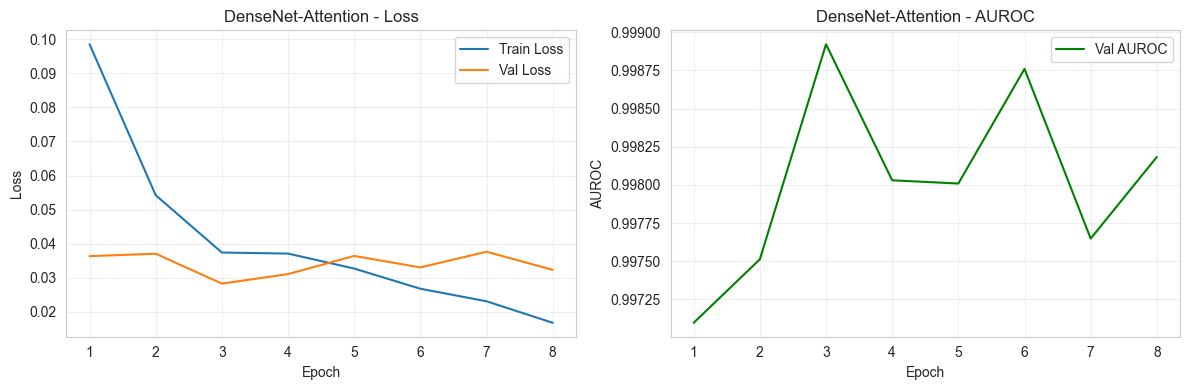

In [7]:
fig = plot_training_history(densenet_history["history"], title="DenseNet-Attention")
plt.savefig("../results/densenet_attention_training.png", bbox_inches="tight")
plt.show()

In [8]:
densenet_test = evaluate_model(densenet_model, dataloaders["test"], device)

print("DenseNet-Attention - Test Results:")
for key in ["auroc", "f1_macro", "sensitivity", "specificity", "precision", "npv", "accuracy"]:
    print(f"  {key:>15s}: {densenet_test['metrics'][key]:.4f}")

print(f"\nThreshold analysis:")
for key, val in densenet_test["threshold_analysis"].items():
    print(f"  {key}: {val:.4f}")

DenseNet-Attention - Test Results:
            auroc: 0.9857
         f1_macro: 0.9273
      sensitivity: 0.9949
      specificity: 0.8333
        precision: 0.9087
              npv: 0.9898
         accuracy: 0.9343

Threshold analysis:
  youden_threshold: 0.9892
  youden_sensitivity: 0.9590
  youden_specificity: 0.9530
  sensitivity95_threshold: 0.0000


## Confusion matrices side by side

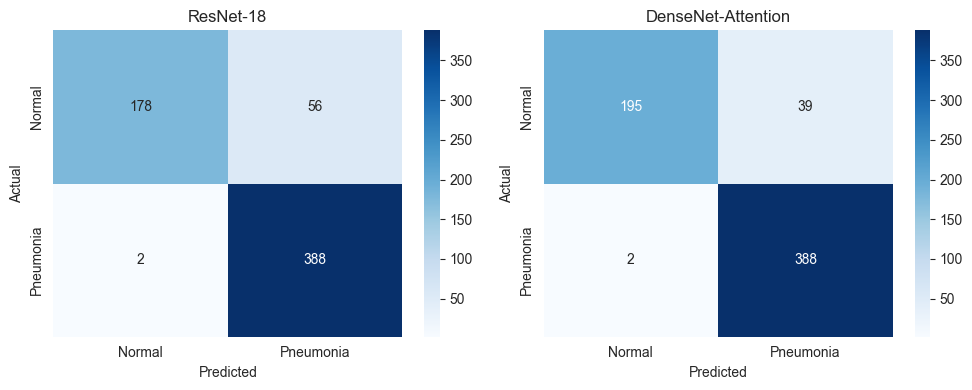

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_confusion_matrix(
    resnet_test["y_true"], resnet_test["y_proba"],
    title="ResNet-18", ax=axes[0],
)
plot_confusion_matrix(
    densenet_test["y_true"], densenet_test["y_proba"],
    title="DenseNet-Attention", ax=axes[1],
)

plt.tight_layout()
plt.savefig("../results/model_confusion_matrices.png", bbox_inches="tight")
plt.show()

## ROC Curve Comparison

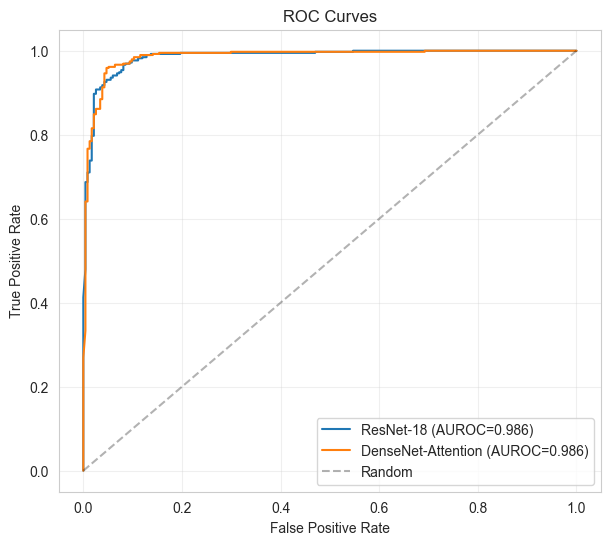

In [10]:
all_results = {
    "ResNet-18": resnet_test,
    "DenseNet-Attention": densenet_test,
}

fig, ax = plt.subplots(figsize=(7, 6))
plot_roc_curve(all_results, ax=ax)
plt.savefig("../results/model_roc_curves.png", bbox_inches="tight")
plt.show()

## Grad-CAM Visualization

We visualize the regions of the X-ray that each model attends to,
to verify the clinical plausibility of the learned features.

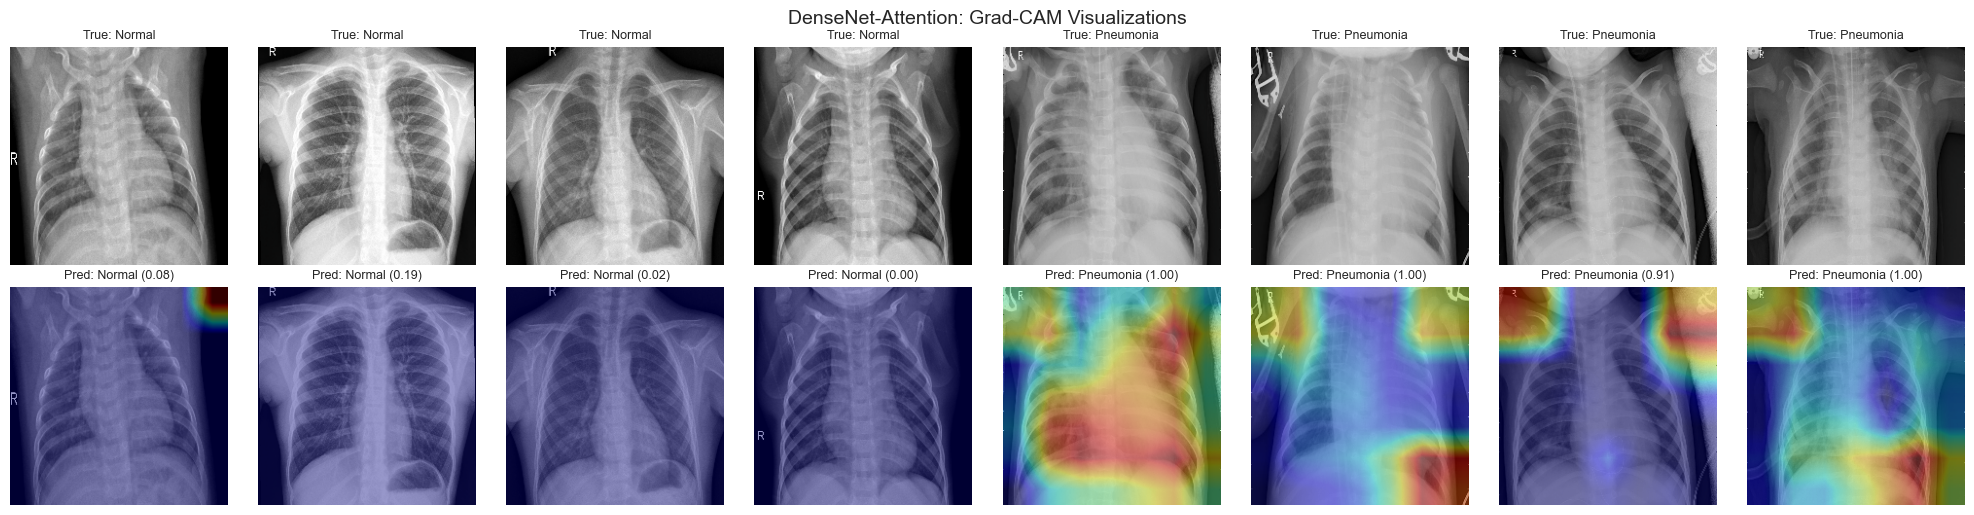

In [17]:
import random
import importlib
import src.evaluate
importlib.reload(src.evaluate)
from src.evaluate import generate_gradcam, plot_gradcam_grid

test_iter = iter(dataloaders["test"])
all_images, all_labels = [], []
for imgs, lbls in test_iter:
    all_images.append(imgs)
    all_labels.append(lbls)
all_images = torch.cat(all_images)
all_labels = torch.cat(all_labels)

normal_idx = (all_labels == 0).nonzero(as_tuple=True)[0]
pneumonia_idx = (all_labels == 1).nonzero(as_tuple=True)[0]

rng = random.Random(42)
selected = (
    [normal_idx[i].item() for i in rng.sample(range(len(normal_idx)), 4)]
    + [pneumonia_idx[i].item() for i in rng.sample(range(len(pneumonia_idx)), 4)]
)

sample_images = all_images[selected]
sample_labels = all_labels[selected]

# Grad-CAM for DenseNet-Attention
target_layer = densenet_model.backbone[-1]

heatmaps = generate_gradcam(densenet_model, sample_images, target_layer, device)

with torch.no_grad():
    preds = torch.sigmoid(densenet_model(sample_images.to(device)).squeeze()).cpu().numpy()

fig = plot_gradcam_grid(sample_images, heatmaps, sample_labels.numpy(), preds, n_samples=8)
plt.suptitle("DenseNet-Attention: Grad-CAM Visualizations", fontsize=14, y=1.02)
plt.savefig("../results/gradcam_densenet.png", bbox_inches="tight")
plt.show()

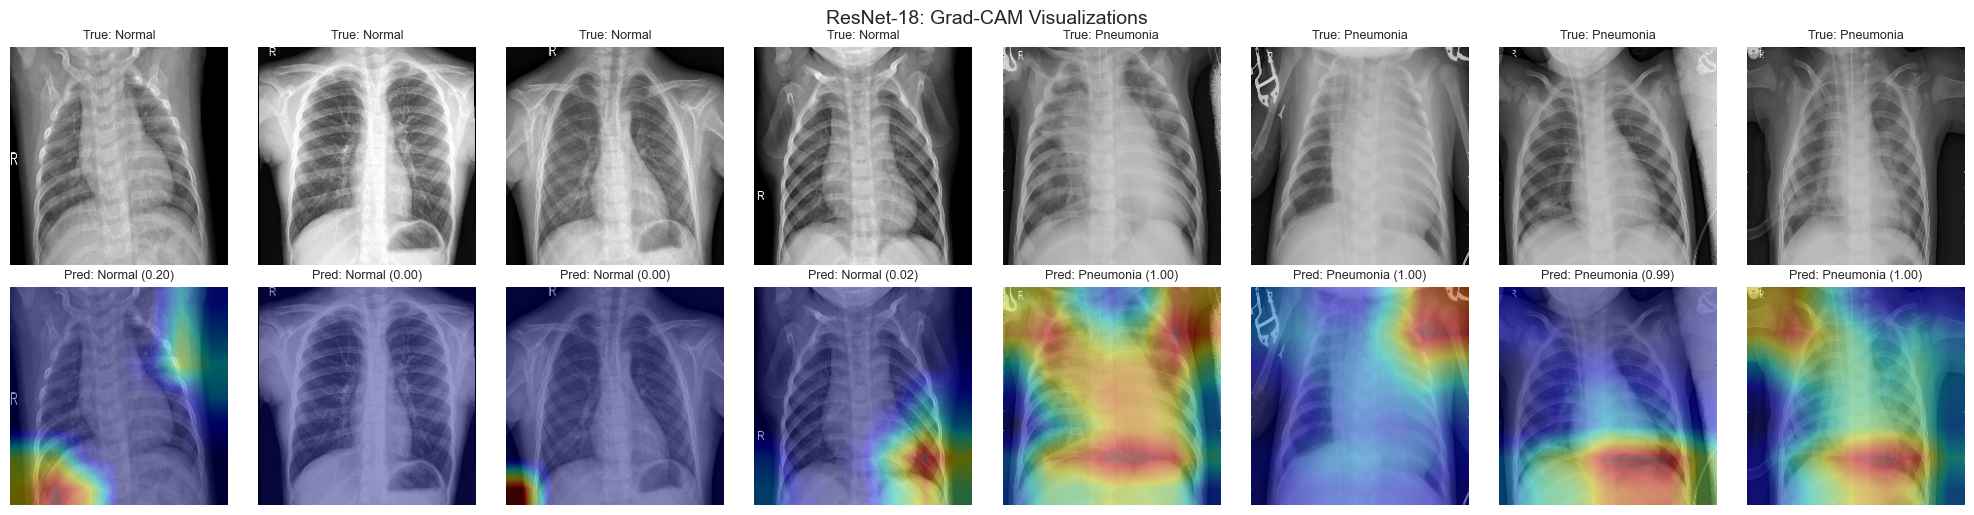

In [18]:
# Grad-CAM for ResNet-18
target_layer_resnet = resnet_model.resnet.layer4[-1]

heatmaps_resnet = generate_gradcam(resnet_model, sample_images, target_layer_resnet, device)

with torch.no_grad():
    preds_resnet = torch.sigmoid(resnet_model(sample_images.to(device)).squeeze()).cpu().numpy()

fig = plot_gradcam_grid(sample_images, heatmaps_resnet, sample_labels.numpy(), preds_resnet, n_samples=8)
plt.suptitle("ResNet-18: Grad-CAM Visualizations", fontsize=14, y=1.02)
plt.savefig("../results/gradcam_resnet.png", bbox_inches="tight")
plt.show()

## Save all results

In [19]:
save_results(
    {
        "resnet18": resnet_test["metrics"],
        "densenet_attention": densenet_test["metrics"],
        "resnet18_threshold": resnet_test["threshold_analysis"],
        "densenet_attention_threshold": densenet_test["threshold_analysis"],
    },
    "model_results",
    output_dir="../results",
)
print("Model results saved.")

Model results saved.


In [20]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()